--- Part 1: Basic Analysis of Iris Dataset ---

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non

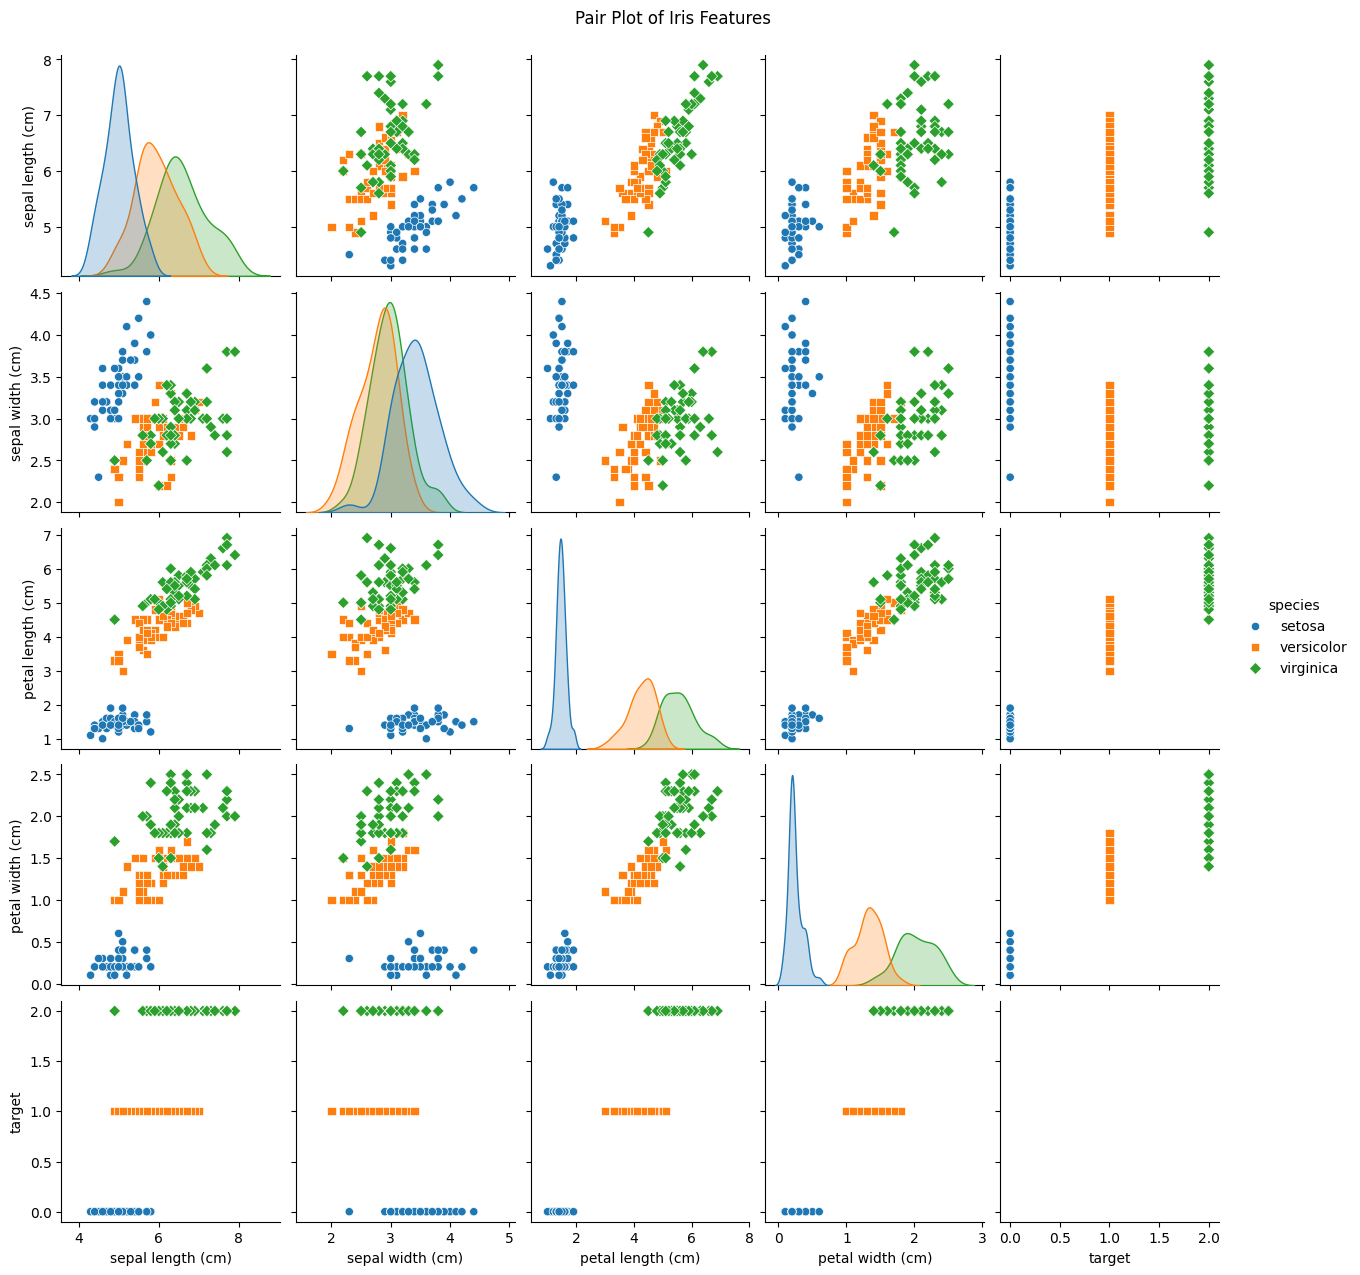

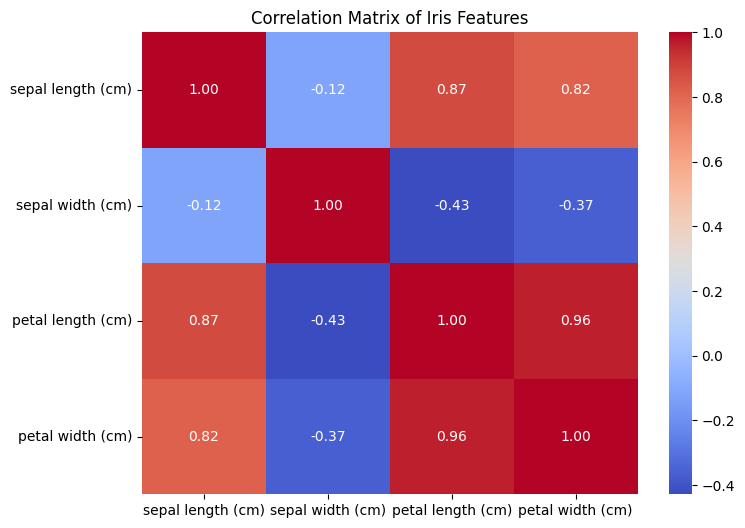


--- Part 2: Autoencoder (AE) for Iris Dataset ---

Autoencoder model summary:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (88.00 B)

 Trainable params: 22 (88.00 B)

 Non-trainable params: 0 (0.00 B)


Training complete.


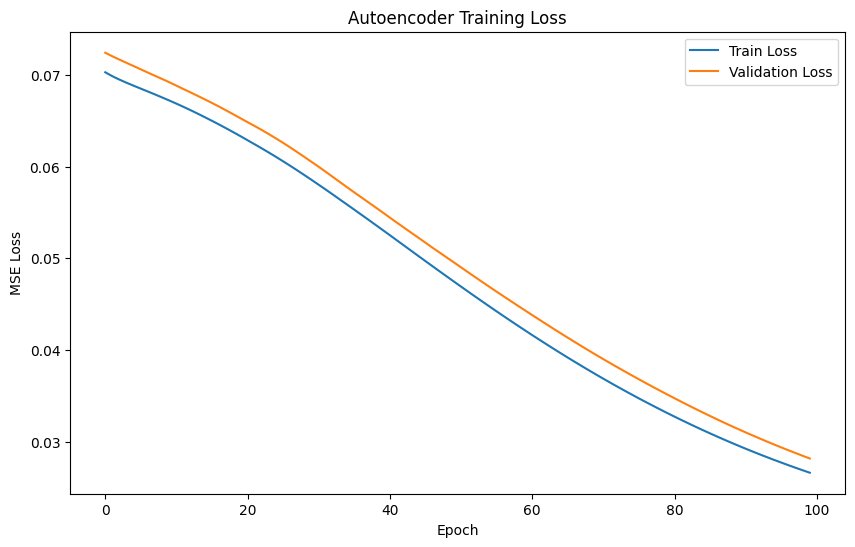

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


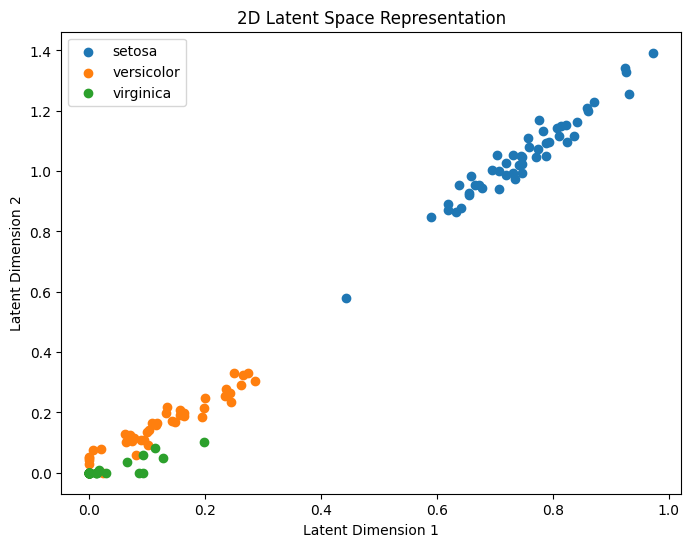

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

Average reconstruction error on test set (MSE): 0.0282

Comparison of original vs reconstructed (first 5 test samples):
Original: [0.5        0.33333333 0.62711864 0.45833333] -> Reconstructed: [0.48168862 0.45403    0.5107562  0.5554694 ]
Original: [0.38888889 0.75       0.11864407 0.08333333] -> Reconstructed: [0.243465   0.5219921  0.24887016 0.14921711]
Original: [0.94444444 0.25       1.         0.91666667] -> Reconstructed: [0.50790757 0.4454591  0.5469646  0.6143816 ]
Original: [0.47222222 0.375      0.59322034 0.58333333] -> Reconstructed: [0.46952584 0.45383513 0.5113561  0.554019  ]
Original: [0.69444444 0.33333333 0.6440678  0.54166667] -> Reconstructed: [0.50790757 0.4454591  0.5469646  0.6143816 ]


In [3]:
# --- Improved Iris Autoencoder Analysis ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import os

# Create folder for figures
os.makedirs("figures", exist_ok=True)

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Part 1: Basic Analysis of Iris Dataset ---
print("--- Part 1: Basic Analysis of Iris Dataset ---")

# Load dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris["target"] = iris.target
df_iris["species"] = df_iris["target"].apply(lambda x: iris.target_names[x])

print("\nFirst 5 rows:\n", df_iris.head())
print("\nDataset info:")
df_iris.info()
print("\nDescriptive statistics:\n", df_iris.describe())
print("\nClass distribution:\n", df_iris["species"].value_counts())

# --- Pair Plot (FIXED) ---
pairplot = sns.pairplot(df_iris, hue="species", markers=["o", "s", "D"])
pairplot.fig.suptitle("Pair Plot of Iris Features", y=1.02)
pairplot.fig.savefig("figures/pairplot_iris.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Correlation Matrix ---
plt.figure(figsize=(8, 6))
sns.heatmap(df_iris.iloc[:, :-2].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Iris Features")
plt.savefig("figures/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Part 2: Autoencoder ---
print("\n--- Part 2: Autoencoder (AE) for Iris Dataset ---")

# Prepare data
X = df_iris.iloc[:, :-2].values

# Scaling (0–1 for sigmoid)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test = train_test_split(
    X_scaled, test_size=0.2, random_state=42
)

# Autoencoder architecture
input_dim = X_train.shape[1]
encoding_dim = 2

# Encoder
input_layer = keras.Input(shape=(input_dim,))
encoded = layers.Dense(encoding_dim, activation="relu")(input_layer)

# Decoder
decoded = layers.Dense(input_dim, activation="sigmoid")(encoded)

# Autoencoder model
autoencoder = keras.Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer="adam", loss="mse")

print("\nAutoencoder model summary:")
autoencoder.summary()

# Train autoencoder
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=100,
    batch_size=16,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=0,
)

print("\nTraining complete.")

# --- Training Loss Plot ---
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.savefig("figures/ae_training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Latent Space Visualization ---
encoder_model = keras.Model(inputs=input_layer, outputs=encoded)
encoded_data = encoder_model.predict(X_scaled)

plt.figure(figsize=(8, 6))
for species_id, species_name in enumerate(iris.target_names):
    plt.scatter(
        encoded_data[df_iris["target"] == species_id, 0],
        encoded_data[df_iris["target"] == species_id, 1],
        label=species_name,
    )

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D Latent Space Representation")
plt.legend()
plt.savefig("figures/latent_space.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Reconstruction Error ---
reconstructed_data = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.square(X_test - reconstructed_data))
print(f"\nAverage reconstruction error on test set (MSE): {reconstruction_error:.4f}")

# --- Original vs Reconstructed ---
print("\nComparison of original vs reconstructed (first 5 test samples):")
for i in range(5):
    print(f"Original: {X_test[i]} -> Reconstructed: {reconstructed_data[i]}")
